<a href="https://colab.research.google.com/github/ish66726-a11y/finance-prep/blob/main/01_foundations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#01 金融数学入門・土台

#1-1 金融市場概観

## 金融市場とは
- お金を「余っている人（投資家）」から「必要な人（企業・政府）」へ橋渡しする場。
- 資金の出し手と取り手が、**価格** を通じて取引する。

---

## 主な市場と参加者

| 市場 | 取引されるもの | 代表的な参加者 |
|------|----------------|----------------|
| 株式市場 | 株式（企業の所有権） | 個人・機関投資家・企業 |
| 債券市場 | 債券（＝借金の証書） | 政府・企業・銀行・年金基金 |
| 為替市場 | 通貨 | 銀行・輸出入企業・ファンド |
| デリバティブ市場 | 先物・オプション等 | ヘッジ目的の企業・投機家・裁定者 |

👉 どの市場でも本質は同じ：「**将来の不確実なキャッシュフローに、今いくら払うか**」を決めている。

---

## なぜ数理（数学）が要るのか
- 金融商品の価値は **将来** に発生する。だが将来は **不確実**。
- 「いつ・いくら・どのくらいの確率で」お金が動くかを扱うには、次の道具が要る。

| 道具 | 役割 | 主に使う章 |
|------|------|-----------|
| 時間価値（割引） | 将来のお金を「今の価値」に直す | 1・2章 |
| 確率・統計 | 不確実な値動きを数式で表す | 1・3章 |
| 無裁定の原則 | 「フリーランチは無い」で価格を一意に決める | 2・3章 |

> 金融数学とは、ひとことで言えば  
> **「不確実な未来のお金を、今の値段に翻訳する技術」** である。

---

### まとめ
👉 金融市場は「将来のお金」を売買する場  
👉 将来は不確実だから、割引・確率・無裁定という数理の道具が要る  
👉 本章でその土台を作り、以降の章で何度も使い回す

#1-2 お金の時間的価値（Time Value of Money）

## 基本の考え方
- 「今日の100円」と「1年後の100円」は **同じ価値ではない**。
- 今日の100円は運用すれば増えるので、将来の100円より価値が高い。

> **お金には時間的価値がある**  
> → 異なる時点のお金を比べるには、まず時点をそろえる必要がある。

---

## 将来価値（FV）と現在価値（PV）

- **将来価値（Future Value, FV）**：今のお金が将来いくらになるか。
  $$FV = PV \times (1+r)^n$$
- **現在価値（Present Value, PV）**：将来のお金は今いくらの価値か。
  $$PV = \frac{FV}{(1+r)^n}$$
  - $r$：1期あたりの金利（割引率）
  - $n$：期数（年数など）

👉 FV と PV は同じ式を逆に解いただけの「表と裏」。

---

## 割引係数（Discount Factor）
- 将来CFを現在価値に直す掛け算ファクター。
  $$DF(n) = \frac{1}{(1+r)^n}$$
- 「将来CF × 割引係数 ＝ 現在価値」と、掛け算1回で割引ける便利な道具。

👉 2章の債券価格は「各CF × 割引係数 の合計」。ここが土台になる。

---

## 複利の頻度：離散複利 ⇔ 連続複利

- **離散複利（年m回）**：1年を m 回に分けて複利する。
  $$FV = PV \left(1 + \frac{r}{m}\right)^{mn}$$
  - m=1：年1回、m=2：半年、m=12：毎月、…
- **連続複利（continuous compounding）**：m→∞ の極限。
  $$FV = PV \cdot e^{rt}$$
- 連続複利は指数・対数で扱えて式がきれいになるため、3章（BSモデル）以降で多用する。

👉 同じ「実質的な増え方」でも、複利頻度が違えば表示金利は変わる。  
👉 異なる頻度の金利を比べるには、頻度をそろえて変換する（`compounding_convert`）。

---

### 実装：fv / pv / discount_factor / compounding_convert

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import date

# 割引係数：1単位の将来CFを現在価値に直す掛け算ファクター
def discount_factor(rate, t, m=1):
    if m is None:                       # 連続複利
        return np.exp(-rate * t)
    return 1 / (1 + rate / m) ** (m * t)


# 将来価値：現在の pv_amount が t 年後にいくらになるか
def fv(pv_amount, rate, t, m=1):
    if m is None:                       # 連続複利
        return pv_amount * np.exp(rate * t)
    return pv_amount * (1 + rate / m) ** (m * t)


# 現在価値：t 年後の fv_amount は今いくらの価値か（割引係数を再利用）
def pv(fv_amount, rate, t, m=1):
    return fv_amount * discount_factor(rate, t, m)


# 複利頻度の変換：いったん「実効年利」に正規化してから目的の頻度へ戻す
# m=None は連続複利を表す
def compounding_convert(rate, m_from, m_to):
    # 1. 元の金利 → 実効年利 r_eff
    if m_from is None:
        r_eff = np.exp(rate) - 1
    else:
        r_eff = (1 + rate / m_from) ** m_from - 1
    # 2. 実効年利 → 目的の頻度での金利
    if m_to is None:
        return np.log(1 + r_eff)
    return m_to * ((1 + r_eff) ** (1 / m_to) - 1)


# ===== 実行部分 =====

# 元本1000円・年4%・2年（年1回複利）
print(f"FV = {fv(1000, 0.04, 2):.2f}円")              # 将来価値
print(f"PV = {pv(1081.60, 0.04, 2):.2f}円")           # 現在価値（FVから逆算）
print(f"DF = {discount_factor(0.04, 2):.4f}")         # 2年後の割引係数

# 年4%（年1回複利）を連続複利に変換 → また年1回に戻す
r_cont = compounding_convert(0.04, 1, None)
print(f"年1回4% → 連続複利 = {r_cont*100:.4f}%")
print(f"連続複利 → 年1回   = {compounding_convert(r_cont, None, 1)*100:.4f}%")

FV = 1081.60円
PV = 1000.00円
DF = 0.9246
年1回4% → 連続複利 = 3.9221%
連続複利 → 年1回   = 4.0000%


#1-3 デイカウントと金利表現

## デイカウント（Day Count Convention）とは
- 「金利は年率○%」と言っても、**1年を何日として数えるか** で利息額が変わる。
- このルールを **デイカウント（日数計算規則）** と呼ぶ。
- 債券・スワップ・ローンなど、商品ごとに慣習が決まっている。

---

## 代表的な規則

| 規則 | 分子（日数） | 分母 | よく使う商品 |
|------|--------------|------|--------------|
| ACT/365 | 実日数 | 365 固定 | 円金利など |
| ACT/360 | 実日数 | 360 固定 | ドル短期金利など |
| 30/360 | 1か月=30日とみなす | 360 固定 | 社債など |

- **ACT（Actual）**：実際のカレンダー日数を数える。
- **30/360**：すべての月を30日として扱い、計算を単純化する。

👉 ここで出る「年数（期間）」は、価格式の指数 $n$ や割引の $t$ にそのまま入る。

> デイカウントは地味だが **金利計算の分母を決める** 重要ルール。  
> 同じ「年4%」でも規則が違えば利息額は変わる。

---

## 名目金利と実効金利

- **名目金利（Nominal Rate）**：「年m回複利」と頻度をセットで示した表示上の金利。
- **実効金利（Effective Rate）**：1年で実際にどれだけ増えたかを、年1回複利に直した金利。
  $$r_{eff} = \left(1 + \frac{r_{nom}}{m}\right)^m - 1$$

- 例：名目12%・毎月複利（m=12）→ 実効 ≒ 12.68%（複利が効くぶん名目より高い）

👉 「どちらが得か」を比べるときは、必ず **実効金利にそろえて** 比較する。  
👉 `effective_rate` は 1-2 の `compounding_convert(rate, m, 1)` と同じ計算（特化版）。

---

### 実装：daycount / effective_rate

In [3]:
# デイカウント：2つの日付の間の「年数（年率換算の分母）」を返す
def daycount(start, end, convention="ACT/365"):
    if convention == "ACT/365":
        return (end - start).days / 365
    elif convention == "ACT/360":
        return (end - start).days / 360
    elif convention == "30/360":
        d1, d2 = start.day, end.day
        d1 = min(d1, 30)                 # 31日は30日として扱う
        if d1 == 30 and d2 == 31:
            d2 = 30
        days = (360 * (end.year - start.year)
                + 30 * (end.month - start.month)
                + (d2 - d1))
        return days / 360
    else:
        raise ValueError(f"未対応の convention: {convention}")


# 実効金利：名目年利（年m回複利）→ 年1回複利に直した実効年利
def effective_rate(nominal, m):
    if m is None:                        # 連続複利
        return np.exp(nominal) - 1
    return (1 + nominal / m) ** m - 1


# ===== 実行部分 =====

start = date(2025, 1, 1)
end   = date(2025, 7, 1)

# 同じ期間でも規則によって年数（分母）が変わる
print(f"ACT/365 : {daycount(start, end, 'ACT/365'):.4f} 年")
print(f"ACT/360 : {daycount(start, end, 'ACT/360'):.4f} 年")
print(f"30/360  : {daycount(date(2025,1,31), date(2025,7,31), '30/360'):.4f} 年")

# 名目12%・毎月複利の実効金利
print(f"実効金利 = {effective_rate(0.12, 12)*100:.2f}%")

ACT/365 : 0.4959 年
ACT/360 : 0.5028 年
30/360  : 0.5000 年
実効金利 = 12.68%


#1-4 資産とリターン

## 価格とリターン
- 投資の成果は「価格そのもの」ではなく **リターン（収益率, return）** で測る。
- 価格 $P_t$ から、隣り合う時点の比でリターンを計算する。

---

## 単純リターンと対数リターン

- **単純リターン（Simple Return）**
  $$R_t = \frac{P_t}{P_{t-1}} - 1$$
  - 直感的（「何%上がった」）。複数資産の合成（ポートフォリオ）に向く。

- **対数リターン（Log Return）**
  $$r_t = \ln\!\frac{P_t}{P_{t-1}}$$
  - 時間方向に足し算できる（加法性）。数式・確率モデルに向く。

| | 単純リターン | 対数リターン |
|---|---|---|
| 直感 | 分かりやすい | やや抽象的 |
| 期間の合成 | 足し算不可 | 足し算できる |
| 主な用途 | ポートフォリオ集計 | 確率モデル・GBM（1-8） |

👉 値動きが小さいとき両者はほぼ一致する（$\ln(1+x)\approx x$）。  
👉 3章以降の株価モデルは対数リターンを前提にする（対数正規性）。

---

## 分析手法の位置づけ
リターンの「振る舞い」をどう捉えるかで、アプローチが分かれる。

| 手法 | 何を見るか | 本シリーズでの扱い |
|------|-----------|--------------------|
| ファンダメンタル分析 | 企業価値・財務 | 概念のみ |
| テクニカル分析 | 過去の価格パターン | 概念のみ |
| クオンツ分析 | 確率・数理モデル | **本命（1〜3章）** |

> 本シリーズは **クオンツ的アプローチ**：  
> リターンを「確率的に動く量」と捉え、数式とコードで扱う。

---

### 実装：リターン計算とヒストグラム

単純リターン 平均=0.113%  標準偏差=1.997%
対数リターン 平均=0.094%  標準偏差=1.992%


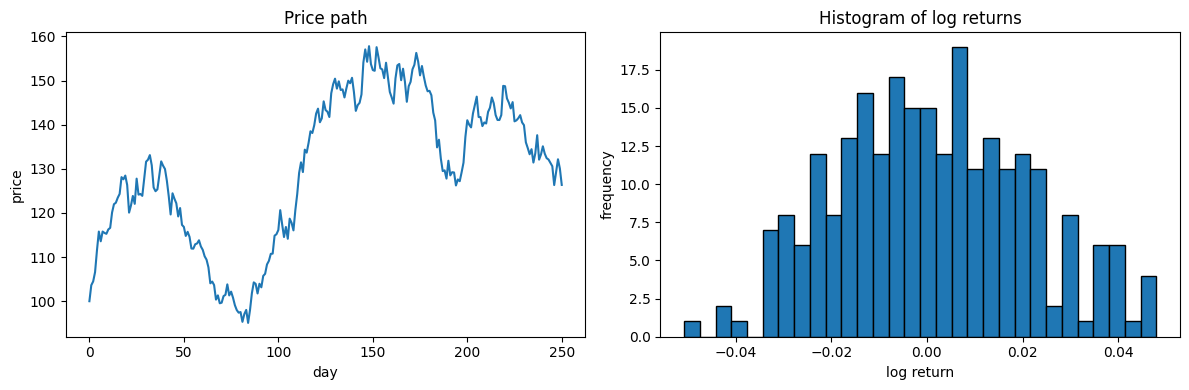

In [4]:
# 単純リターン：R_t = P_t / P_{t-1} - 1
def simple_returns(prices):
    prices = np.asarray(prices, dtype=float)
    return prices[1:] / prices[:-1] - 1


# 対数リターン：r_t = ln(P_t / P_{t-1})
def log_returns(prices):
    prices = np.asarray(prices, dtype=float)
    return np.log(prices[1:] / prices[:-1])


# ===== 実行部分 =====

# サンプル価格系列を生成（後章で出てくる確率的な値動きの簡易版）
np.random.seed(0)
n_days = 250
shocks = np.random.normal(0.0003, 0.02, n_days)   # 日次のランダムな変動
prices = 100 * np.exp(np.cumsum(shocks))          # 初期値100から価格を生成
prices = np.insert(prices, 0, 100.0)

# 2種類のリターンを計算
r_simple = simple_returns(prices)
r_log = log_returns(prices)
print(f"単純リターン 平均={r_simple.mean()*100:.3f}%  標準偏差={r_simple.std()*100:.3f}%")
print(f"対数リターン 平均={r_log.mean()*100:.3f}%  標準偏差={r_log.std()*100:.3f}%")

# 可視化：価格の推移 と 対数リターンの分布
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(prices)
ax[0].set_title("Price path")
ax[0].set_xlabel("day"); ax[0].set_ylabel("price")

ax[1].hist(r_log, bins=30, edgecolor="black")
ax[1].set_title("Histogram of log returns")
ax[1].set_xlabel("log return"); ax[1].set_ylabel("frequency")

plt.tight_layout()
plt.show()